In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.stats as st
import itertools




### ---------- Le nettoyage du jeu de données -------------------

In [11]:
data = pd.read_csv('student_habits_performance.csv')
#chargement de jeux de donnees 

In [12]:
data.head()
#pour afficher les 5 premier lignes de data 

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [13]:
data.shape
#nombre des coline et des linges 

(1000, 16)

In [14]:
nb_na=data.isnull().sum()
print ("les varaible contenant les valeurs manquants ")
print (nb_na[nb_na>0])


les varaible contenant les valeurs manquants 
parental_education_level    91
dtype: int64


In [15]:
#remplace les valeurs manquants 
data.loc[data['parental_education_level'].isnull(),'parental_education_level']='Unknow'

In [16]:
#On retire 'student_id' car il ne sera pas utile pour l'ACP
data.drop(columns=['student_id'] , inplace=True )

In [17]:
data.describe() 

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [18]:
data.drop_duplicates(inplace=True, ignore_index=True) 
#suprimme les doublans , (inplace = true pour remplacer dans data originale )

In [19]:
print (data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [20]:
masque_coherence= (
    (data['study_hours_per_day'] <= 24 ) &
    (data['attendance_percentage'] <=100) &
    (data['exam_score'] <= 100) & 
    (data['age'] >= 16) & (data['age']<=30)

)



In [21]:
data=data[masque_coherence]

In [22]:
#detection des outilier par IQR sur l'examen 
Q1= data['exam_score'].quantile(0.25)
Q3= data['exam_score'].quantile(0.75)
IQR=Q3-Q1
borne_inf=Q1-1.5*IQR
borne_sup=Q3+1.5*IQR
print (f"borne inferieur {borne_inf} " )
print(f" borne sup {borne_sup}")
outliers_exam = data[(data['exam_score'] < borne_inf) | (data['exam_score'] > borne_sup)]
print(f"Nombre d'outliers détectés pour le score : {len(outliers_exam)}")
print (f'les outiliers sont : {outliers_exam}')
print("Décision : On conserve ces valeurs car elles sont cohérentes avec la réalité (étudiants performants).")

borne inferieur 24.199999999999996 
 borne sup 115.60000000000001
Nombre d'outliers détectés pour le score : 2
les outiliers sont :      age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
265   18  Female                  0.6                 3.1            3.0   
327   23    Male                  0.9                 2.4            2.5   

    part_time_job  attendance_percentage  sleep_hours diet_quality  \
265            No                   79.9          5.2         Good   
327            No                   89.2          6.9         Fair   

     exercise_frequency parental_education_level internet_quality  \
265                   1                 Bachelor             Good   
327                   0              High School             Poor   

     mental_health_rating extracurricular_participation  exam_score  
265                     4                            No        18.4  
327                     1                            No        23.1  
Décision :

# --------- Analyse monovariée--------------

#### ------------------ ANALYSE MONOVARIÉE( Varaible Qualitative)--------------------------


--- Distribution de gender ---
gender
Female    0.481
Male      0.477
Other     0.042
Name: proportion, dtype: float64


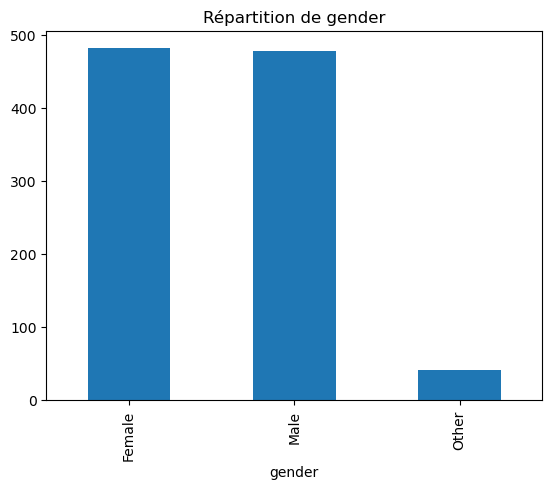


--- Distribution de part_time_job ---
part_time_job
No     0.785
Yes    0.215
Name: proportion, dtype: float64


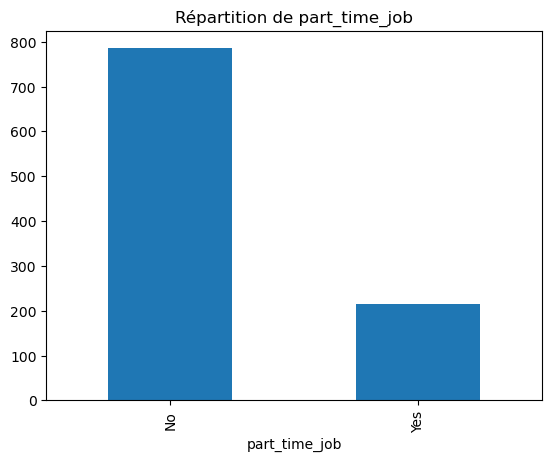


--- Distribution de diet_quality ---
diet_quality
Fair    0.437
Good    0.378
Poor    0.185
Name: proportion, dtype: float64


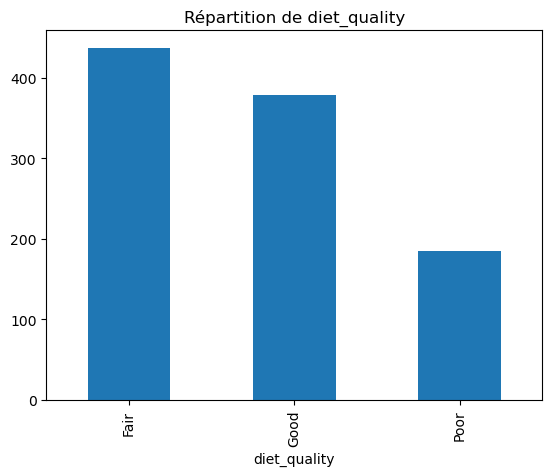


--- Distribution de parental_education_level ---
parental_education_level
High School    0.392
Bachelor       0.350
Master         0.167
Unknow         0.091
Name: proportion, dtype: float64


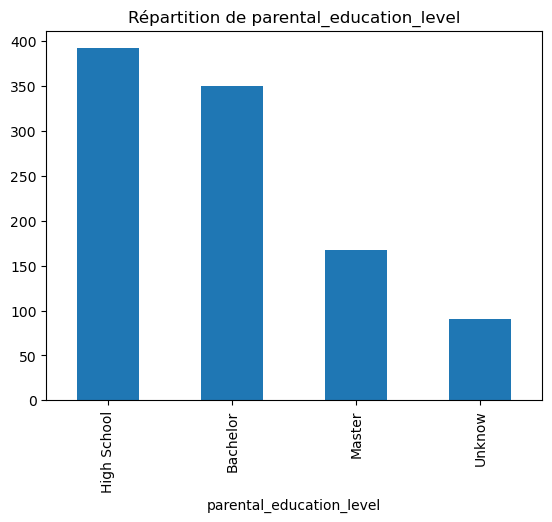


--- Distribution de internet_quality ---
internet_quality
Good       0.447
Average    0.391
Poor       0.162
Name: proportion, dtype: float64


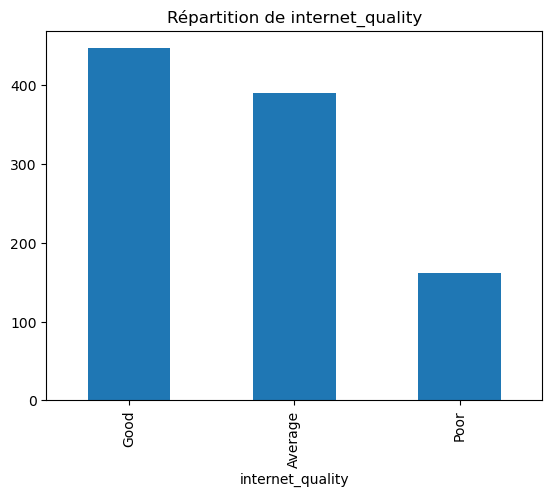


--- Distribution de extracurricular_participation ---
extracurricular_participation
No     0.682
Yes    0.318
Name: proportion, dtype: float64


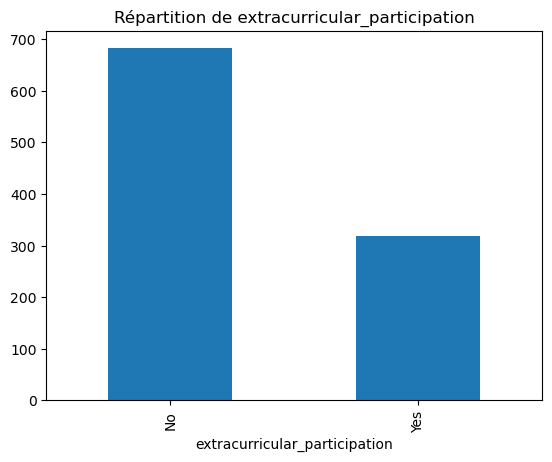

In [25]:
# --- ANALYSE MONOVARIÉE ---



# Pour les variables qualitatives
cols_cat = data.select_dtypes(include=['object']).columns
for col in cols_cat:
    print(f"\n--- Distribution de {col} ---")
    print(data[col].value_counts(normalize=True)) # Fréquences (selon le cours)
    
    data[col].value_counts().plot(kind='bar', title=f'Répartition de {col}')
    plt.show()

### ---------- ANALYSE MONOVARIÉE( Varaible Quantitative)--------------


=== ANALYSE ET VISUALISATION DE : age ===
count    1000.0000
mean       20.4980
std         2.3081
min        17.0000
25%        18.7500
50%        20.0000
75%        23.0000
max        24.0000
Name: age, dtype: float64
Moyenne : 20.50
Écart-type : 2.31
Variance empirique : 5.32
Mode : 20
Asymétrie (Skewness) : 0.01
Aplatissement (Kurtosis) : -1.22


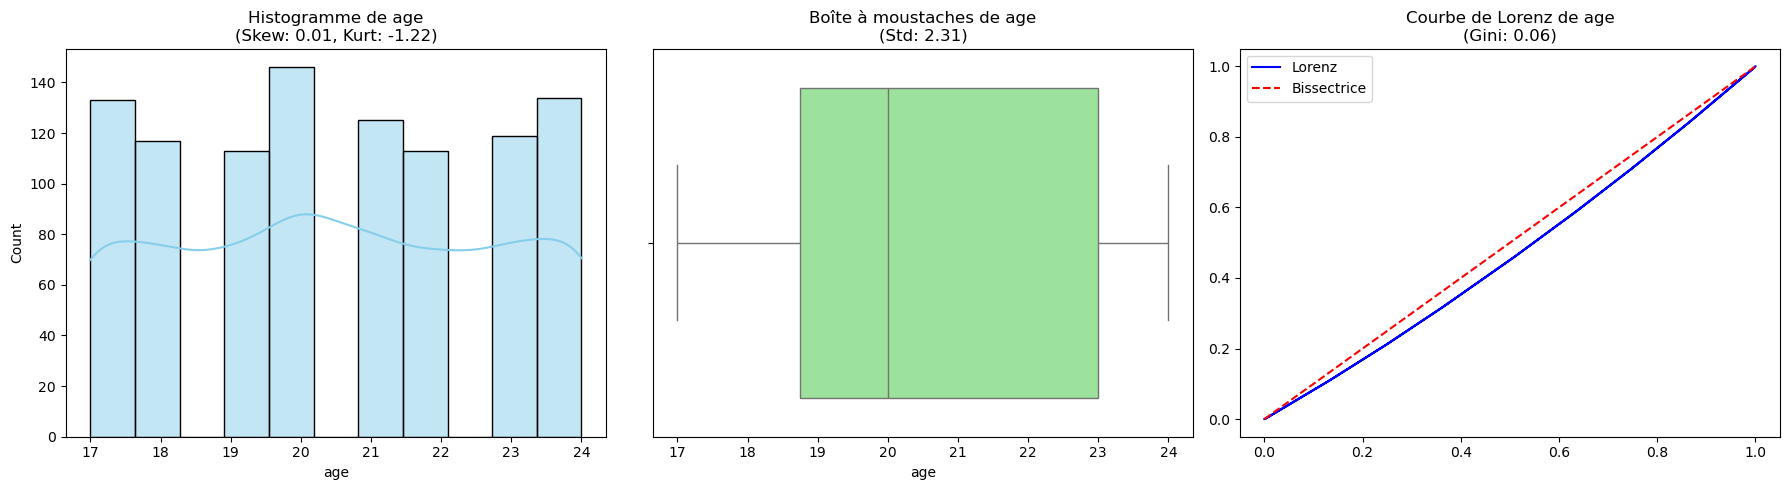


=== ANALYSE ET VISUALISATION DE : study_hours_per_day ===
count    1000.00000
mean        3.55010
std         1.46889
min         0.00000
25%         2.60000
50%         3.50000
75%         4.50000
max         8.30000
Name: study_hours_per_day, dtype: float64
Moyenne : 3.55
Écart-type : 1.47
Variance empirique : 2.16
Mode : 3.5
Asymétrie (Skewness) : 0.05
Aplatissement (Kurtosis) : -0.06


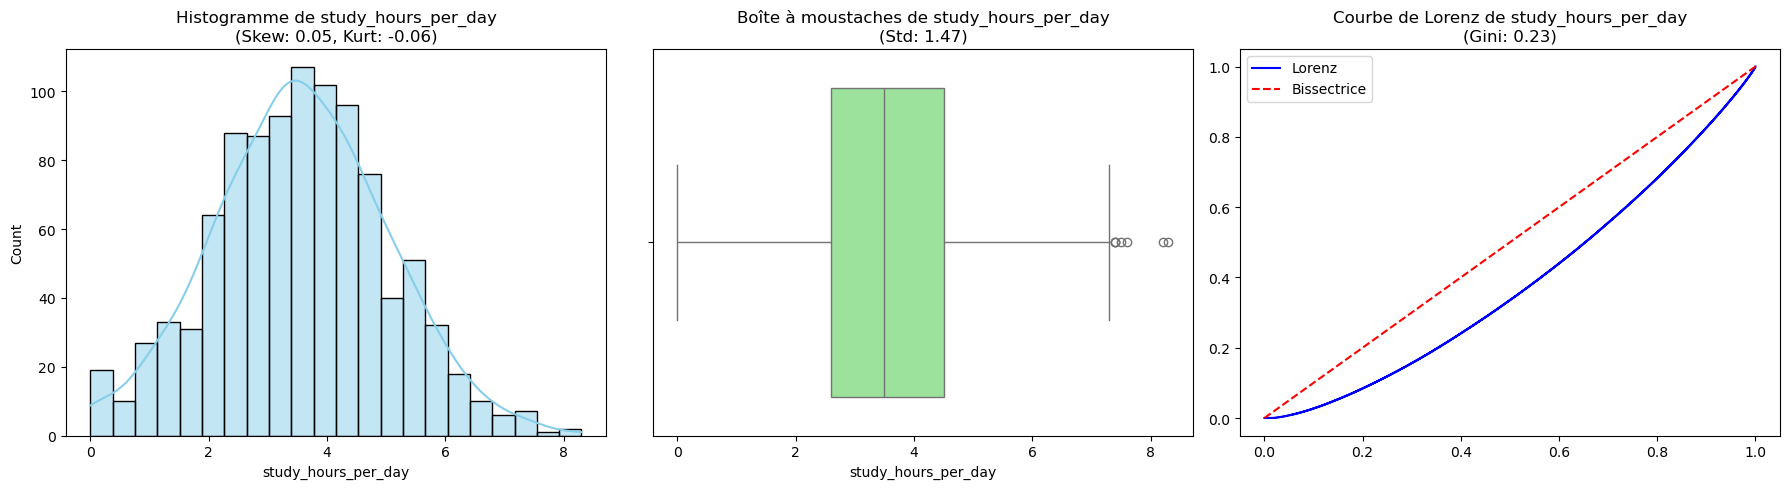


=== ANALYSE ET VISUALISATION DE : social_media_hours ===
count    1000.000000
mean        2.505500
std         1.172422
min         0.000000
25%         1.700000
50%         2.500000
75%         3.300000
max         7.200000
Name: social_media_hours, dtype: float64
Moyenne : 2.51
Écart-type : 1.17
Variance empirique : 1.37
Mode : 3.1
Asymétrie (Skewness) : 0.12
Aplatissement (Kurtosis) : -0.09


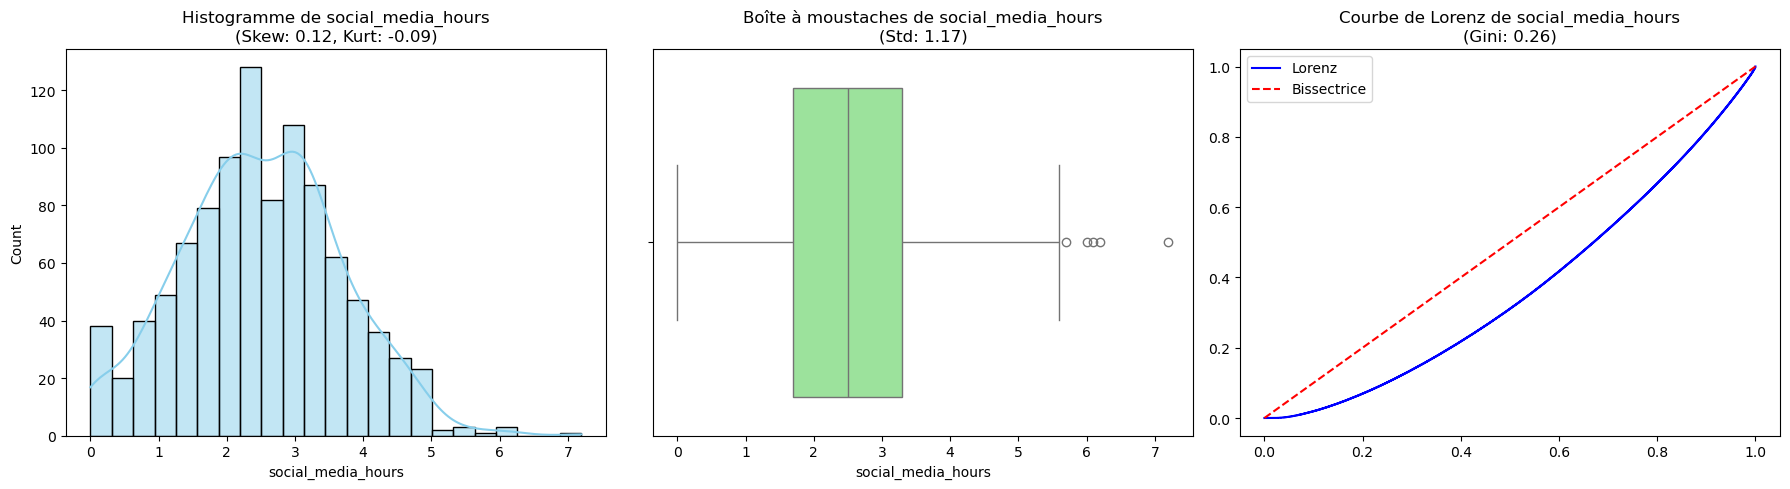


=== ANALYSE ET VISUALISATION DE : netflix_hours ===
count    1000.000000
mean        1.819700
std         1.075118
min         0.000000
25%         1.000000
50%         1.800000
75%         2.525000
max         5.400000
Name: netflix_hours, dtype: float64
Moyenne : 1.82
Écart-type : 1.07
Variance empirique : 1.15
Mode : 0.0
Asymétrie (Skewness) : 0.24
Aplatissement (Kurtosis) : -0.43


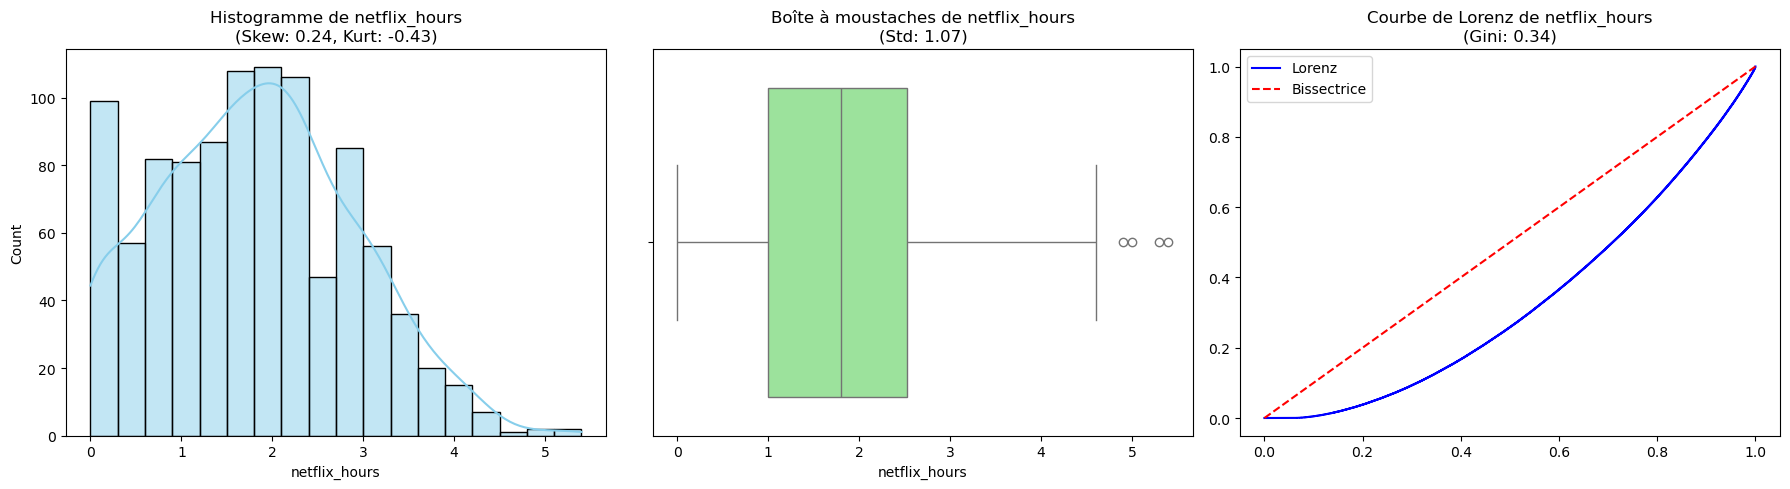


=== ANALYSE ET VISUALISATION DE : attendance_percentage ===
count    1000.000000
mean       84.131700
std         9.399246
min        56.000000
25%        78.000000
50%        84.400000
75%        91.025000
max       100.000000
Name: attendance_percentage, dtype: float64
Moyenne : 84.13
Écart-type : 9.39
Variance empirique : 88.26
Mode : 100.0
Asymétrie (Skewness) : -0.24
Aplatissement (Kurtosis) : -0.39


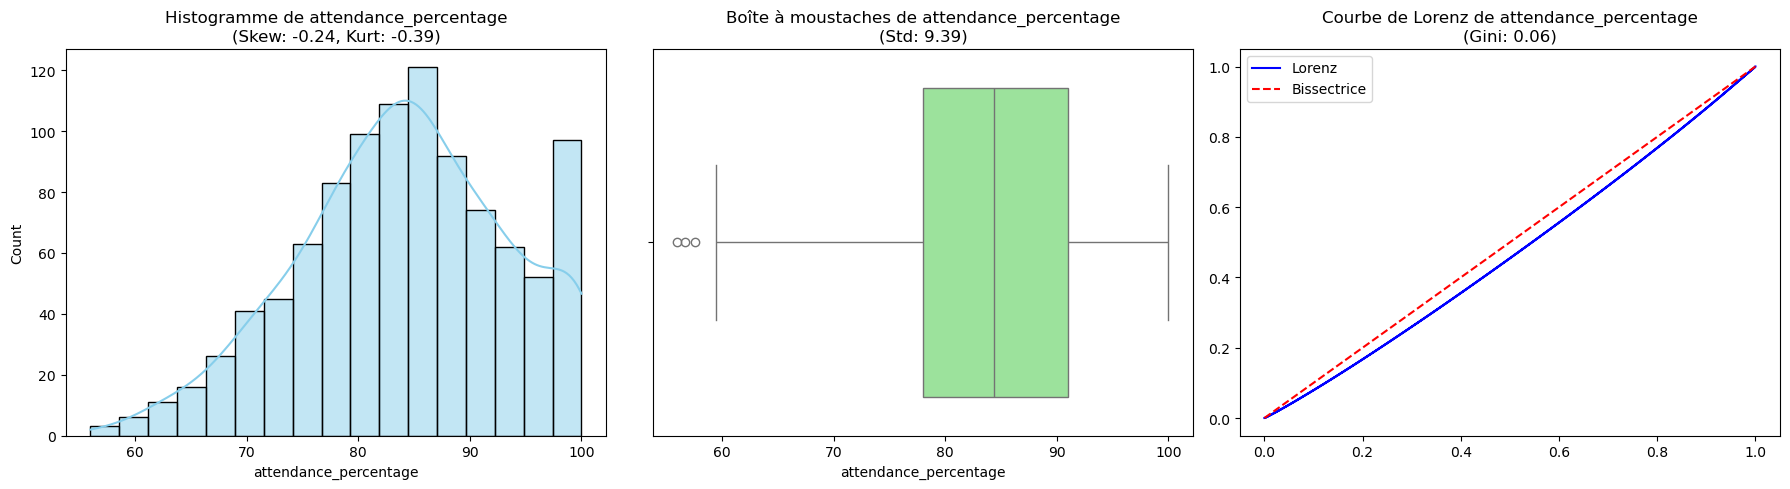


=== ANALYSE ET VISUALISATION DE : sleep_hours ===
count    1000.000000
mean        6.470100
std         1.226377
min         3.200000
25%         5.600000
50%         6.500000
75%         7.300000
max        10.000000
Name: sleep_hours, dtype: float64
Moyenne : 6.47
Écart-type : 1.23
Variance empirique : 1.50
Mode : 6.5
Asymétrie (Skewness) : 0.09
Aplatissement (Kurtosis) : -0.21


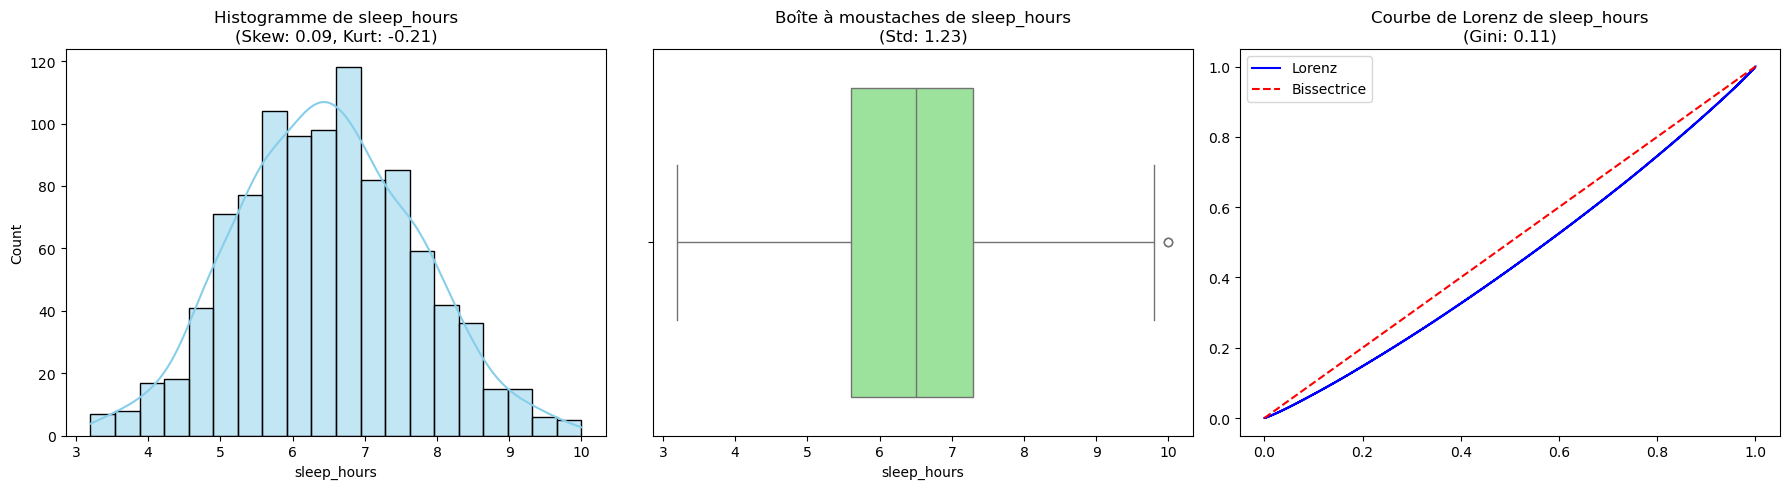


=== ANALYSE ET VISUALISATION DE : exercise_frequency ===
count    1000.000000
mean        3.042000
std         2.025423
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: exercise_frequency, dtype: float64
Moyenne : 3.04
Écart-type : 2.02
Variance empirique : 4.10
Mode : 3
Asymétrie (Skewness) : -0.03
Aplatissement (Kurtosis) : -1.28


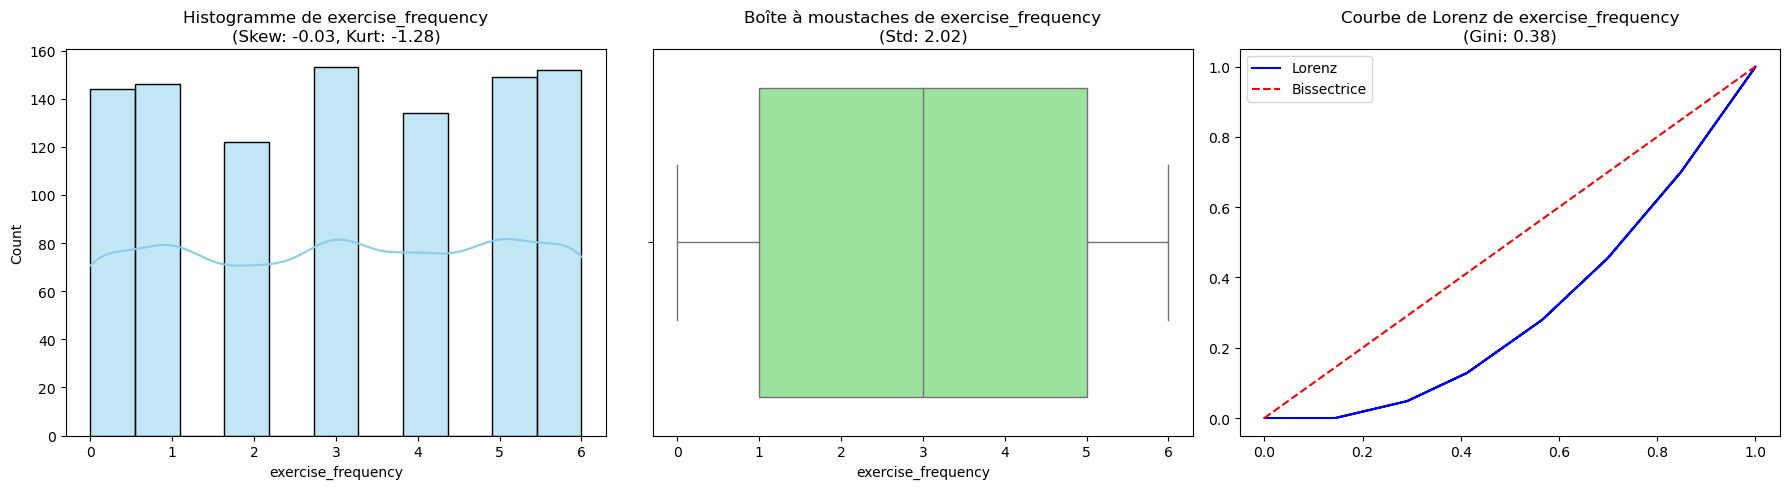


=== ANALYSE ET VISUALISATION DE : mental_health_rating ===
count    1000.000000
mean        5.438000
std         2.847501
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: mental_health_rating, dtype: float64
Moyenne : 5.44
Écart-type : 2.85
Variance empirique : 8.10
Mode : 4
Asymétrie (Skewness) : 0.04
Aplatissement (Kurtosis) : -1.19


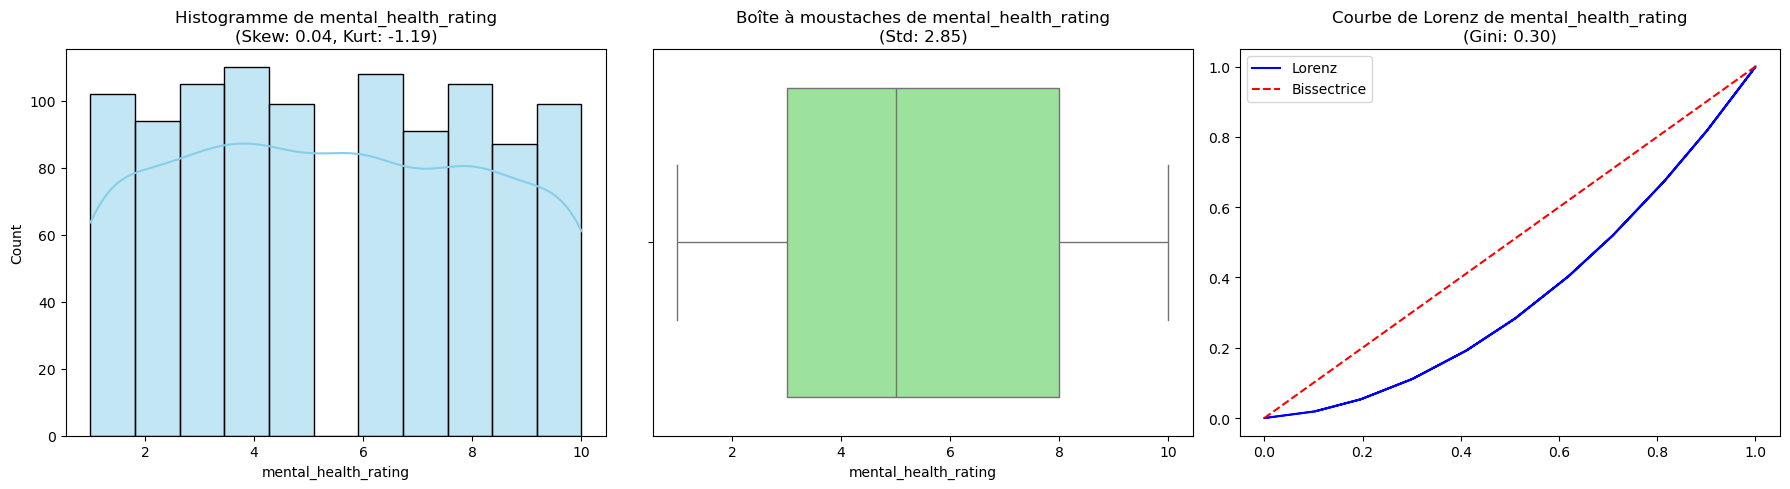


=== ANALYSE ET VISUALISATION DE : exam_score ===
count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64
Moyenne : 69.60
Écart-type : 16.88
Variance empirique : 284.94
Mode : 100.0
Asymétrie (Skewness) : -0.16
Aplatissement (Kurtosis) : -0.42


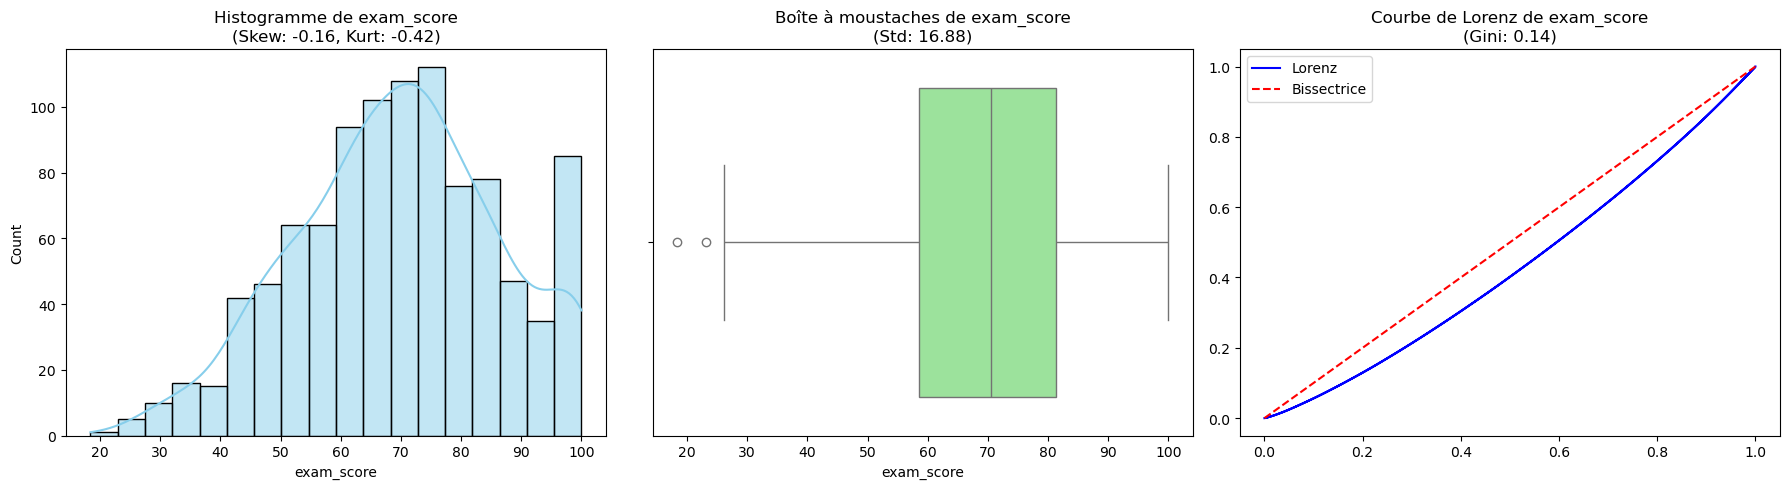

In [27]:
vars_quanti = data.select_dtypes(include=[np.number]).columns

for col in vars_quanti:
    print(f"\n=== ANALYSE ET VISUALISATION DE : {col} ===")
    
    # Statistiques descriptives
    print(data[col].describe())
    std_emp = data[col].std(ddof=0)
    moyenne = data[col].mean()
    variance_emp = data[col].var(ddof=0)
    mode_val = data[col].mode()[0]
    skew = data[col].skew()
    kurt = data[col].kurtosis()
    print(f"Moyenne : {moyenne:.2f}")
    print(f"Écart-type : {std_emp:.2f}")
    print(f"Variance empirique : {variance_emp:.2f}")
    print(f"Mode : {mode_val}")
    print(f"Asymétrie (Skewness) : {skew:.2f}")
    print(f"Aplatissement (Kurtosis) : {kurt:.2f}")
   
    
    # Courbe de Lorenz et coefficient de Gini
    valeurs = np.sort(data[col].values)
    lorenz = np.cumsum(valeurs) / valeurs.sum()
    lorenz = np.insert(lorenz, 0, 0)  # Ajouter 0 au début
    n = len(valeurs)
    aire_sous_lorenz = (lorenz.sum() - lorenz[-1]/2 - lorenz[0]/2) / n
    gini = 2 * (0.5 - aire_sous_lorenz)
    
    # Visualisations
    plt.figure(figsize=(18, 5))
    
    # A) Histogramme + KDE
    plt.subplot(1, 3, 1)
    sns.histplot(data[col], kde=True, color="skyblue")
    plt.title(f"Histogramme de {col}\n(Skew: {skew:.2f}, Kurt: {kurt:.2f})")
    
    # B) Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(f"Boîte à moustaches de {col}\n(Std: {std_emp:.2f})")
    
    # C) Courbe de Lorenz
    plt.subplot(1, 3, 3)
    xaxis = np.linspace(0, 1, len(lorenz))
    plt.plot(xaxis, lorenz, drawstyle='steps-post', color='blue', label='Lorenz')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Bissectrice')
    plt.title(f"Courbe de Lorenz de {col}\n(Gini: {gini:.2f})")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# --------------------Analyse bivariée--------------

### ----------------Analyse bivariée(Quantitative × quantitative)-------------

### ------------------(exemple : Heures d'étude et Score)----------------------

=== ANALYSE BIVARIÉE : exam_score vs study_hours_per_day ===
Coefficient de corrélation (Pearson) : 0.825
Covariance empirique : 20.46


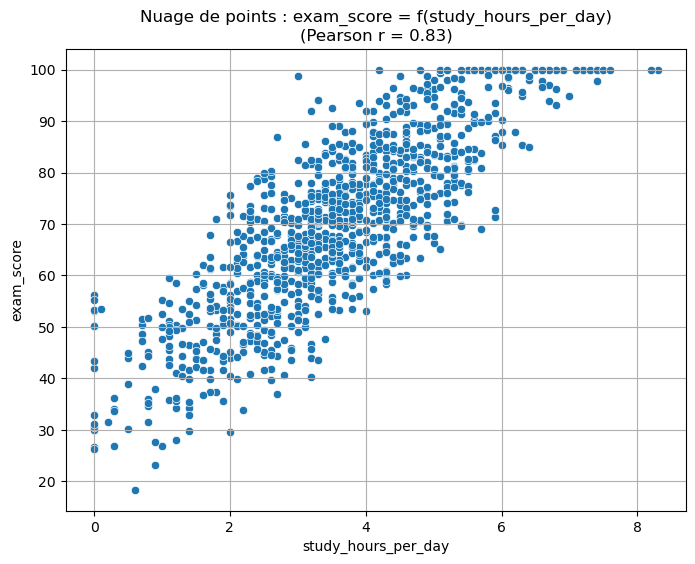

In [31]:
# On choisit deux variables à corréler 
var_x = 'study_hours_per_day'
var_y = 'exam_score'

print(f"=== ANALYSE BIVARIÉE : {var_y} vs {var_x} ===")

# 1. CALCULS STATISTIQUES (Syntaxe exacte du cours)
# Le coefficient de corrélation de Pearson
# [0] car la fonction renvoie (coefficient, p-value)
coeff_pearson = st.pearsonr(data[var_x], data[var_y])[0]

# La covariance empirique (ddof=0)
# [1,0] car np.cov renvoie une matrice, on veut l'élément hors diagonale
covariance = np.cov(data[var_x], data[var_y], ddof=0)[1, 0]

print(f"Coefficient de corrélation (Pearson) : {coeff_pearson:.3f}")
print(f"Covariance empirique : {covariance:.2f}")

# 2. VISUALISATION (Scatter Plot)
plt.figure(figsize=(8, 6))
# On utilise seaborn pour le nuage de points
sns.scatterplot(x=data[var_x], y=data[var_y])

plt.title(f"Nuage de points : {var_y} = f({var_x})\n(Pearson r = {coeff_pearson:.2f})")
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.grid(True)
plt.show()

### ---------------Matrice de Corrélation (Pour toutes les variables)-----------

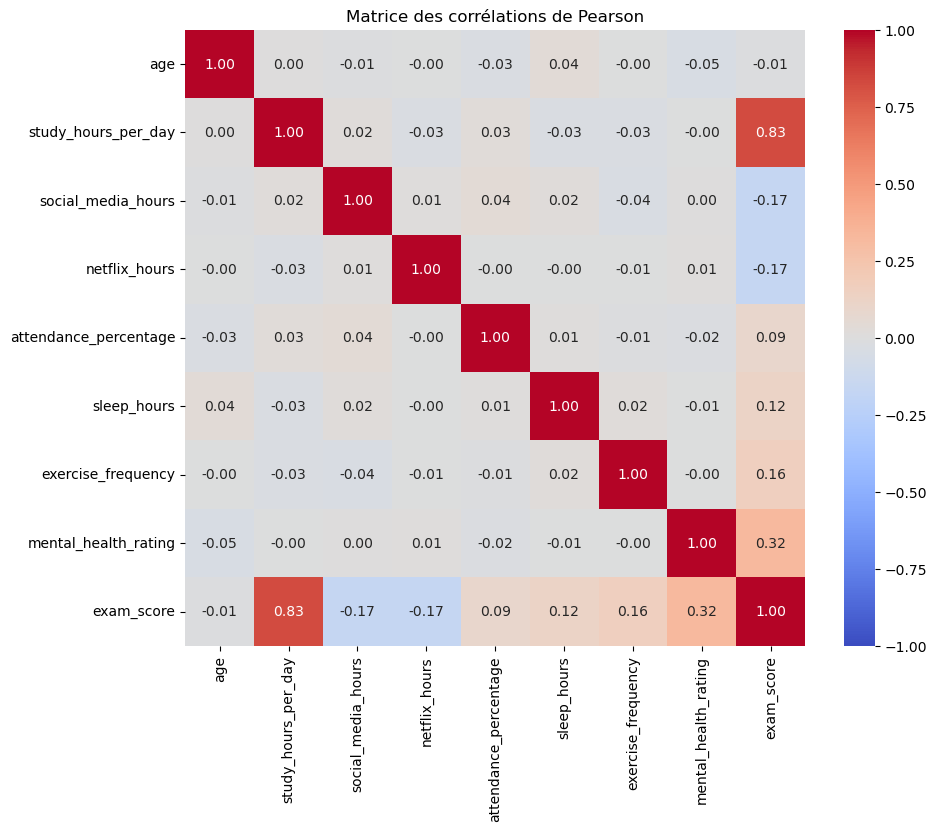

In [33]:
    # Sélection des colonnes numériques
cols_num = data.select_dtypes(include=[np.number]).columns

# Calcul de la matrice de corrélation
matrix_corr = data[cols_num].corr()

# Affichage avec une Heatmap colorée
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice des corrélations de Pearson")
plt.show()

### ---------ANALYSE BIVARIÉE : TOUTES LES QUALITATIVES VS SCORE -------


--- Analyse de l'influence de : gender ---
Rapport de corrélation (h2) pour gender : 0.0003


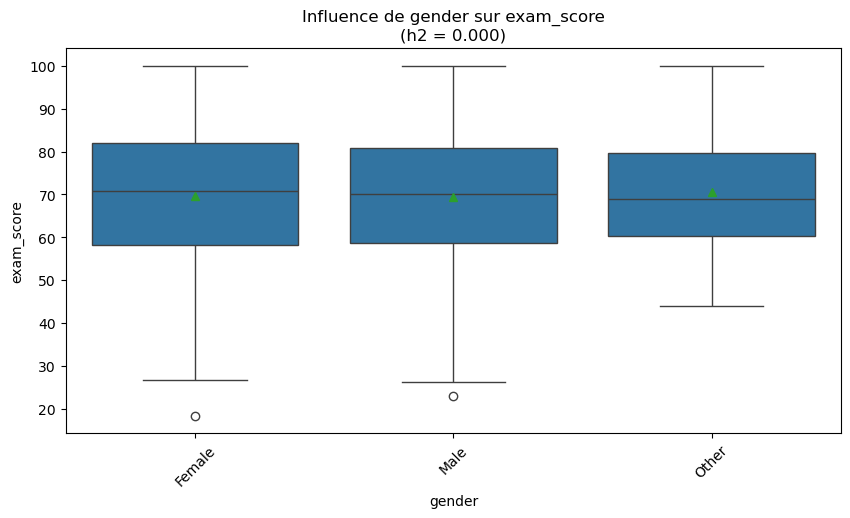


--- Analyse de l'influence de : part_time_job ---
Rapport de corrélation (h2) pour part_time_job : 0.0007


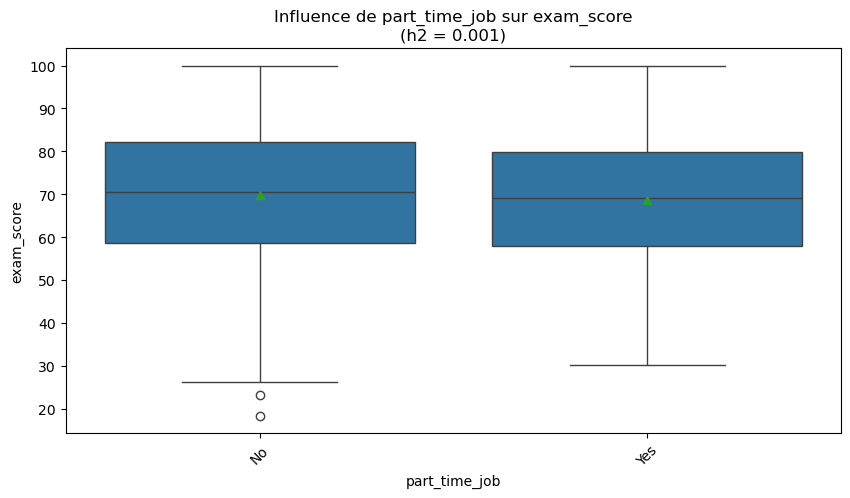


--- Analyse de l'influence de : diet_quality ---
Rapport de corrélation (h2) pour diet_quality : 0.0025


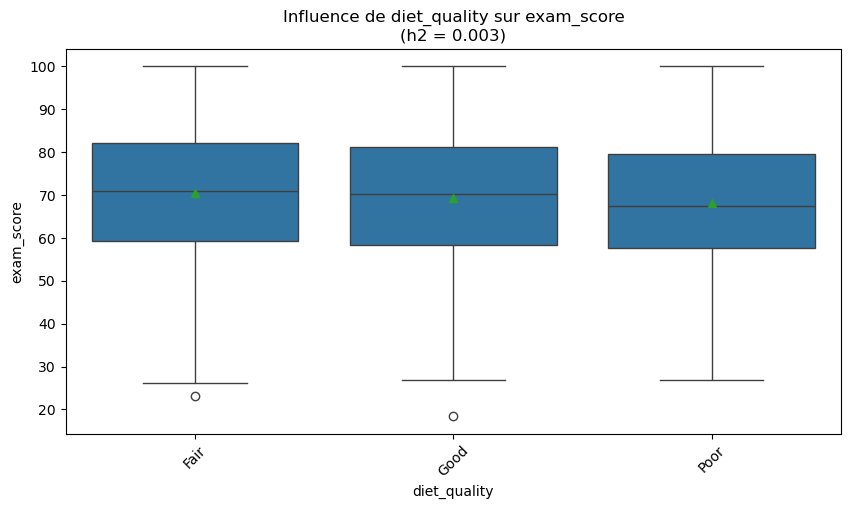


--- Analyse de l'influence de : parental_education_level ---
Rapport de corrélation (h2) pour parental_education_level : 0.0020


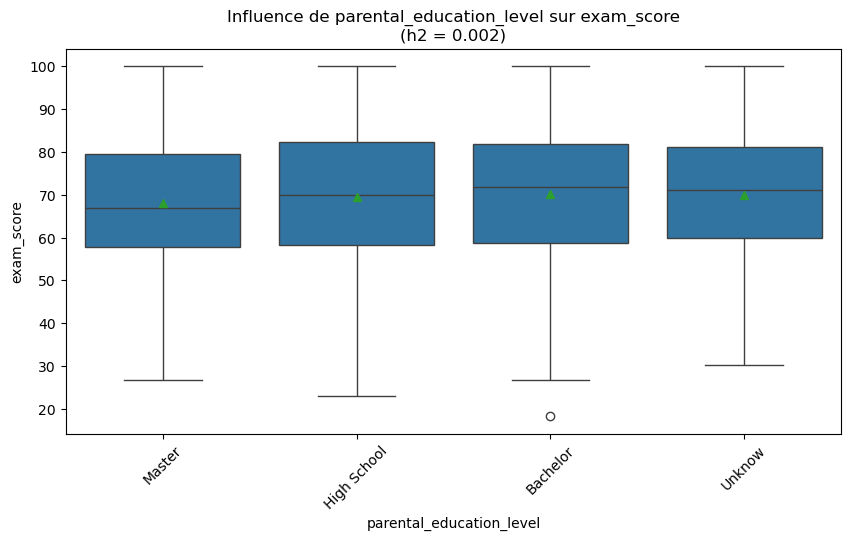


--- Analyse de l'influence de : internet_quality ---
Rapport de corrélation (h2) pour internet_quality : 0.0029


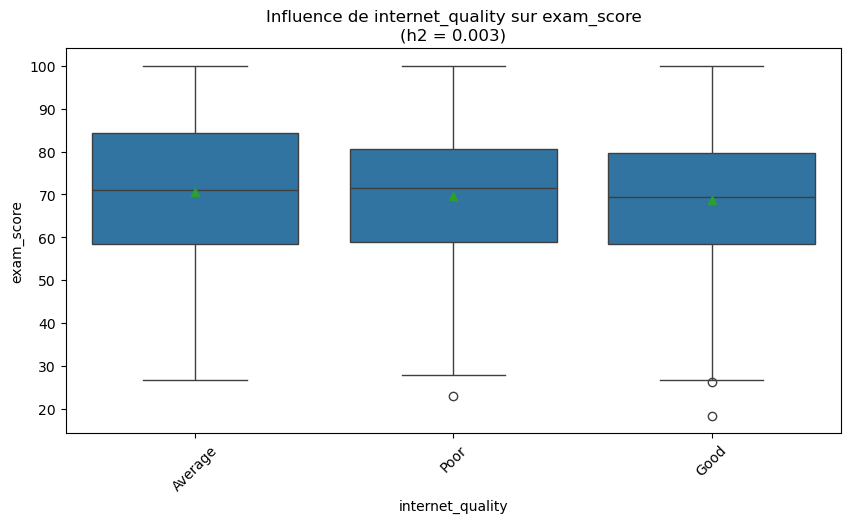


--- Analyse de l'influence de : extracurricular_participation ---
Rapport de corrélation (h2) pour extracurricular_participation : 0.0000


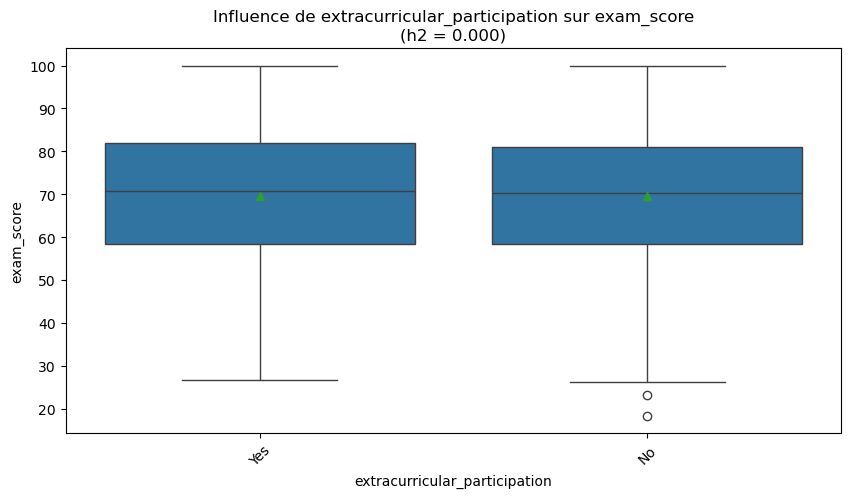

In [35]:
# --- ANALYSE BIVARIÉE : TOUTES LES QUALITATIVES VS SCORE ---

variable_quanti_cible = 'exam_score'
cols_quali = data.select_dtypes(include=['object']).columns

for col_quali in cols_quali:
    print(f"\n--- Analyse de l'influence de : {col_quali} ---")
    
    # 1. Calcul du rapport de corrélation h2 (syntaxe page 67)
    # On réutilise la logique Vinterclasses / Vtotale
    moyenne_y = data[variable_quanti_cible].mean()
    v_totale = data[variable_quanti_cible].var(ddof=0)
    v_inter = 0
    
    for modalite in data[col_quali].unique():
        sub_df = data[data[col_quali] == modalite]
        ni = len(sub_df)
        moyenne_classe = sub_df[variable_quanti_cible].mean()
        v_inter += ni * (moyenne_classe - moyenne_y)**2
    
    h2 = (v_inter / len(data)) / v_totale
    print(f"Rapport de corrélation (h2) pour {col_quali} : {h2:.4f}")
    
    # 2. Visualisation par Boxplot (Figure 30 du cours)
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=data[col_quali], y=data[variable_quanti_cible], showmeans=True)
    plt.title(f"Influence de {col_quali} sur {variable_quanti_cible}\n(h2 = {h2:.3f})")
    plt.xticks(rotation=45)
    plt.show()

### --------ANALYSE BIVARIÉE :Qualitative × qualitative ( KHI-2) --------

Nombre de paires qualitatives à analyser : 15

ANALYSE : gender vs part_time_job

Tableau de contingence (Effectifs observés) :


part_time_job,No,Yes
gender,,
Female,385,96
Male,368,109
Other,32,10


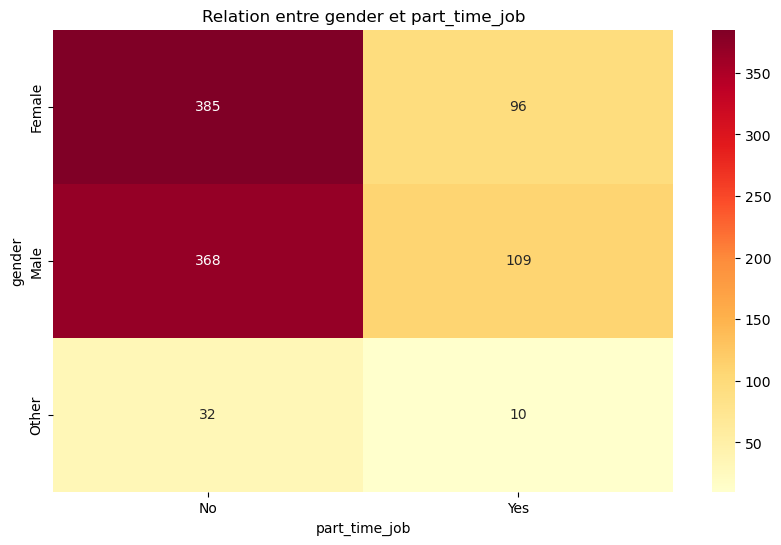


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 1.33
- P-value : 0.5153
👉 Conclusion : gender et part_time_job semblent être indépendantes (p > 0.05).

ANALYSE : gender vs diet_quality

Tableau de contingence (Effectifs observés) :


diet_quality,Fair,Good,Poor
gender,,,
Female,210,179,92
Male,209,185,83
Other,18,14,10


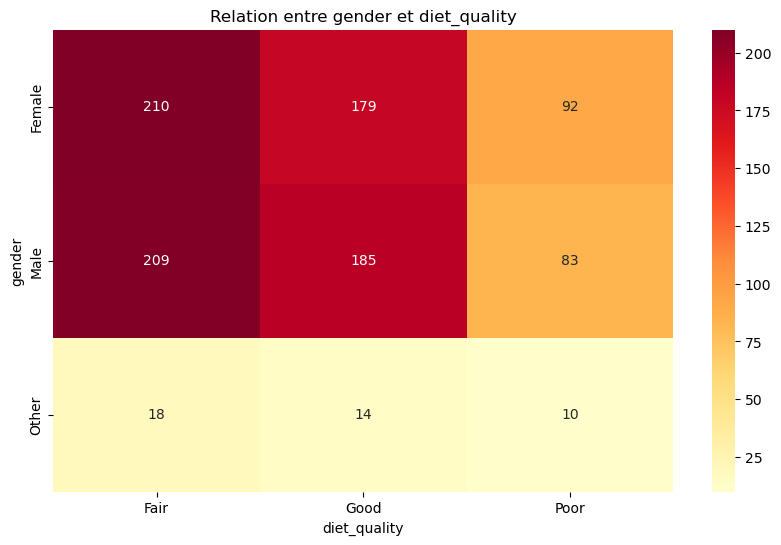


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 1.45
- P-value : 0.8355
👉 Conclusion : gender et diet_quality semblent être indépendantes (p > 0.05).

ANALYSE : gender vs parental_education_level

Tableau de contingence (Effectifs observés) :


parental_education_level,Bachelor,High School,Master,Unknow
gender,,,,
Female,177,177,79,48
Male,165,194,81,37
Other,8,21,7,6


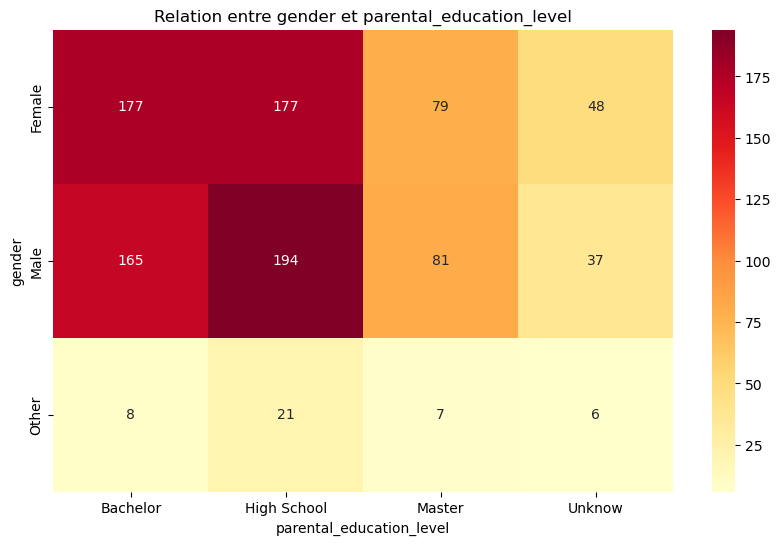


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 8.38
- P-value : 0.2115
👉 Conclusion : gender et parental_education_level semblent être indépendantes (p > 0.05).

ANALYSE : gender vs internet_quality

Tableau de contingence (Effectifs observés) :


internet_quality,Average,Good,Poor
gender,,,
Female,196,220,65
Male,181,205,91
Other,14,22,6


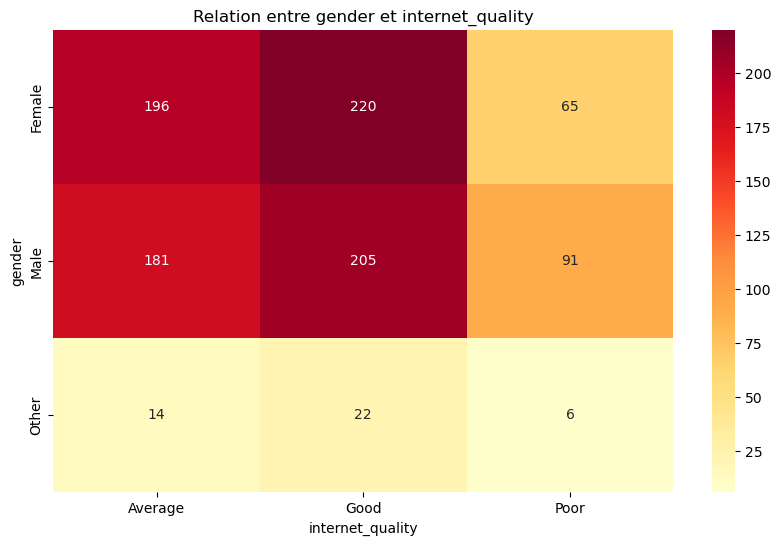


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 6.52
- P-value : 0.1637
👉 Conclusion : gender et internet_quality semblent être indépendantes (p > 0.05).

ANALYSE : gender vs extracurricular_participation

Tableau de contingence (Effectifs observés) :


extracurricular_participation,No,Yes
gender,,
Female,327,154
Male,327,150
Other,28,14


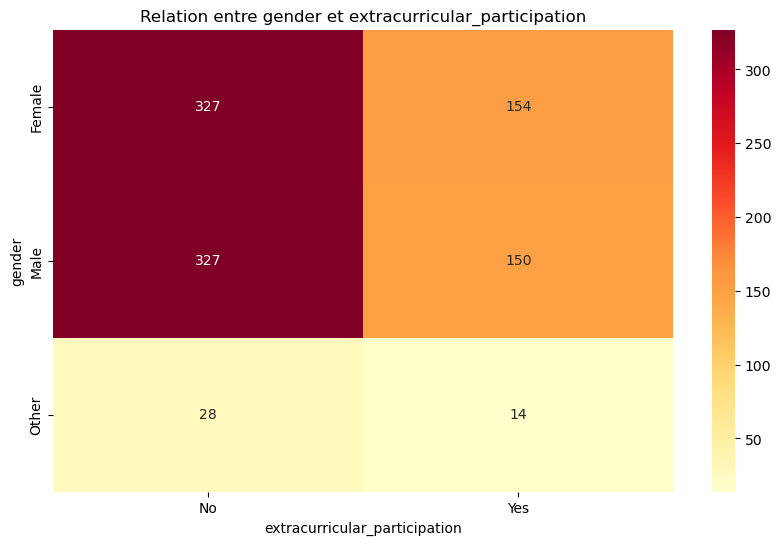


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 0.08
- P-value : 0.9591
👉 Conclusion : gender et extracurricular_participation semblent être indépendantes (p > 0.05).

ANALYSE : part_time_job vs diet_quality

Tableau de contingence (Effectifs observés) :


diet_quality,Fair,Good,Poor
part_time_job,,,
No,346,290,149
Yes,91,88,36


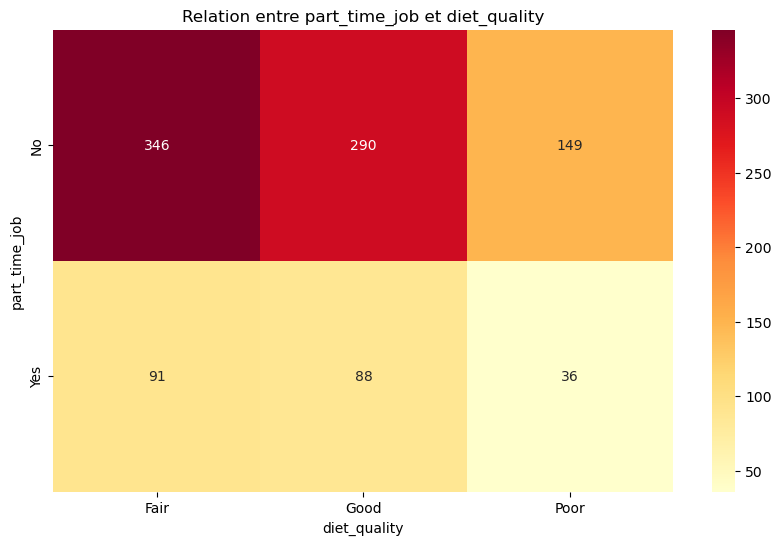


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 1.28
- P-value : 0.5260
👉 Conclusion : part_time_job et diet_quality semblent être indépendantes (p > 0.05).

ANALYSE : part_time_job vs parental_education_level

Tableau de contingence (Effectifs observés) :


parental_education_level,Bachelor,High School,Master,Unknow
part_time_job,,,,
No,282,299,132,72
Yes,68,93,35,19


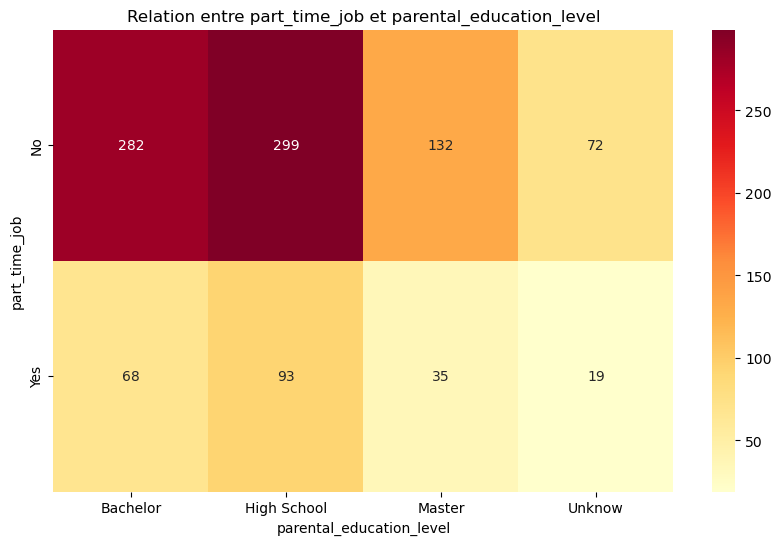


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 2.09
- P-value : 0.5541
👉 Conclusion : part_time_job et parental_education_level semblent être indépendantes (p > 0.05).

ANALYSE : part_time_job vs internet_quality

Tableau de contingence (Effectifs observés) :


internet_quality,Average,Good,Poor
part_time_job,,,
No,294,356,135
Yes,97,91,27


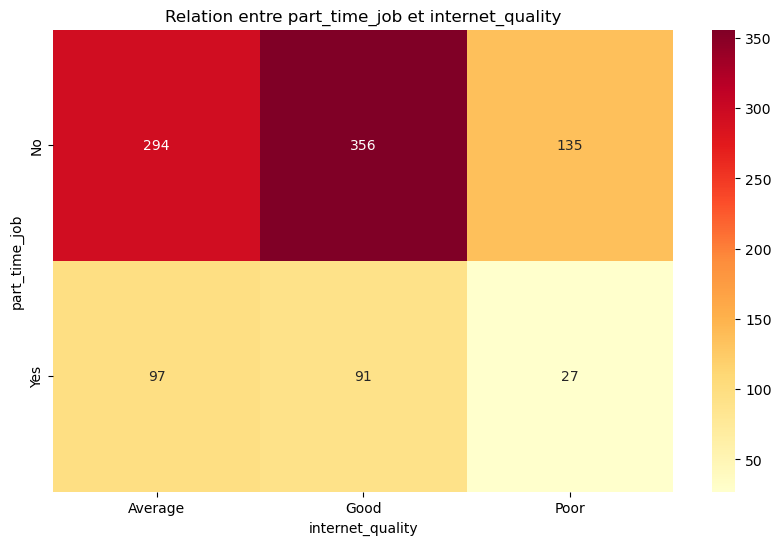


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 5.12
- P-value : 0.0772
👉 Conclusion : part_time_job et internet_quality semblent être indépendantes (p > 0.05).

ANALYSE : part_time_job vs extracurricular_participation

Tableau de contingence (Effectifs observés) :


extracurricular_participation,No,Yes
part_time_job,,
No,531,254
Yes,151,64


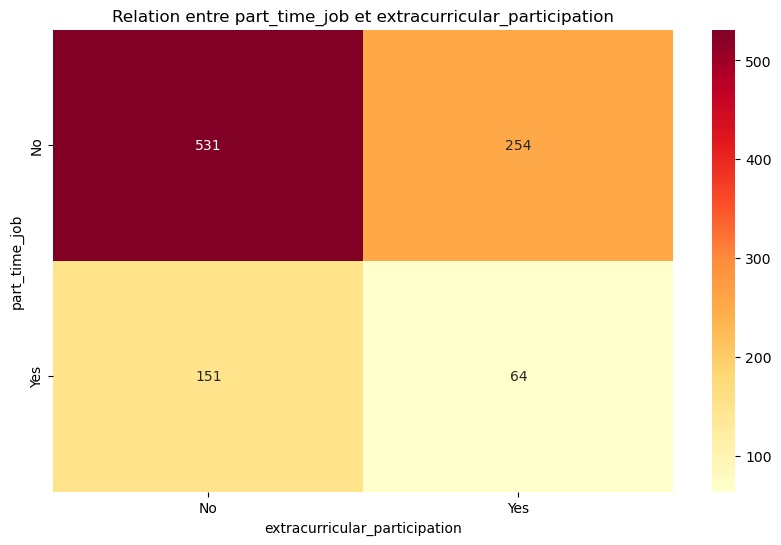


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 0.41
- P-value : 0.5224
👉 Conclusion : part_time_job et extracurricular_participation semblent être indépendantes (p > 0.05).

ANALYSE : diet_quality vs parental_education_level

Tableau de contingence (Effectifs observés) :


parental_education_level,Bachelor,High School,Master,Unknow
diet_quality,,,,
Fair,157,167,72,41
Good,130,156,61,31
Poor,63,69,34,19


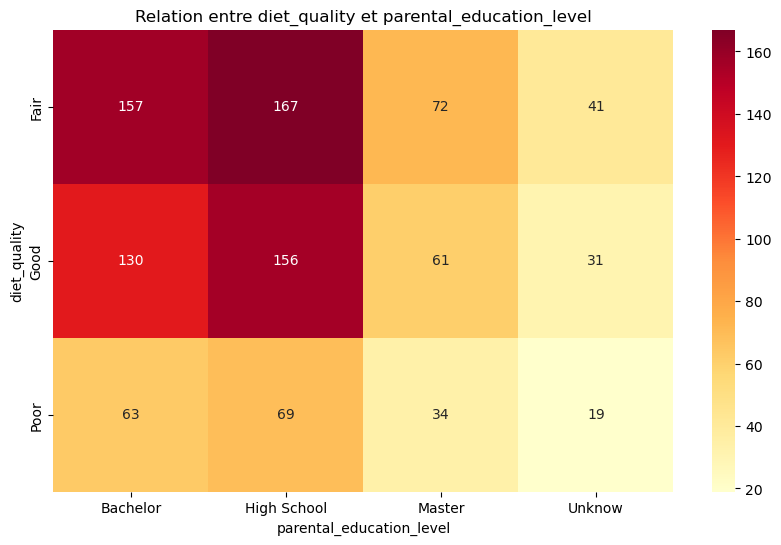


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 1.94
- P-value : 0.9255
👉 Conclusion : diet_quality et parental_education_level semblent être indépendantes (p > 0.05).

ANALYSE : diet_quality vs internet_quality

Tableau de contingence (Effectifs observés) :


internet_quality,Average,Good,Poor
diet_quality,,,
Fair,167,198,72
Good,143,176,59
Poor,81,73,31


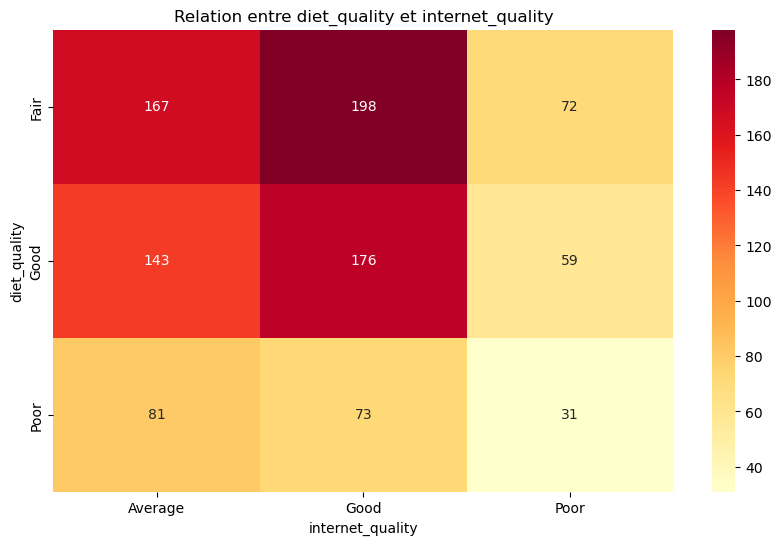


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 2.88
- P-value : 0.5773
👉 Conclusion : diet_quality et internet_quality semblent être indépendantes (p > 0.05).

ANALYSE : diet_quality vs extracurricular_participation

Tableau de contingence (Effectifs observés) :


extracurricular_participation,No,Yes
diet_quality,,
Fair,310,127
Good,257,121
Poor,115,70


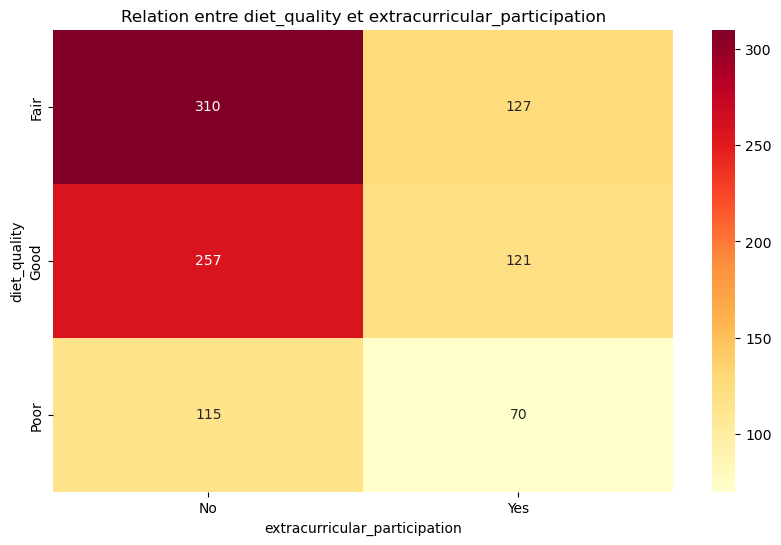


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 4.63
- P-value : 0.0989
👉 Conclusion : diet_quality et extracurricular_participation semblent être indépendantes (p > 0.05).

ANALYSE : parental_education_level vs internet_quality

Tableau de contingence (Effectifs observés) :


internet_quality,Average,Good,Poor
parental_education_level,,,
Bachelor,136,158,56
High School,156,169,67
Master,60,83,24
Unknow,39,37,15


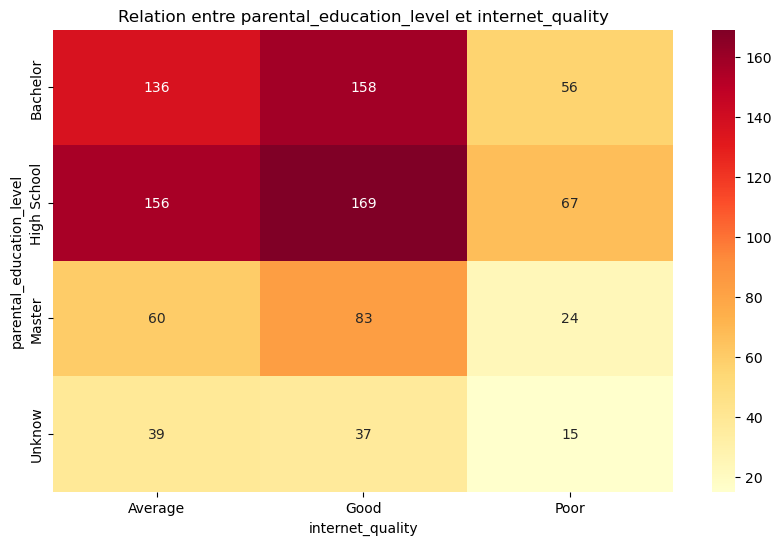


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 2.87
- P-value : 0.8255
👉 Conclusion : parental_education_level et internet_quality semblent être indépendantes (p > 0.05).

ANALYSE : parental_education_level vs extracurricular_participation

Tableau de contingence (Effectifs observés) :


extracurricular_participation,No,Yes
parental_education_level,,
Bachelor,236,114
High School,268,124
Master,116,51
Unknow,62,29


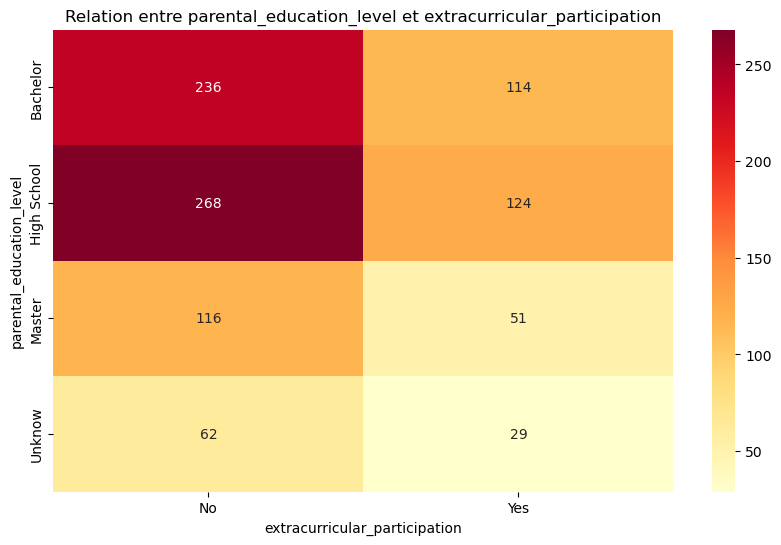


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 0.22
- P-value : 0.9737
👉 Conclusion : parental_education_level et extracurricular_participation semblent être indépendantes (p > 0.05).

ANALYSE : internet_quality vs extracurricular_participation

Tableau de contingence (Effectifs observés) :


extracurricular_participation,No,Yes
internet_quality,,
Average,267,124
Good,310,137
Poor,105,57


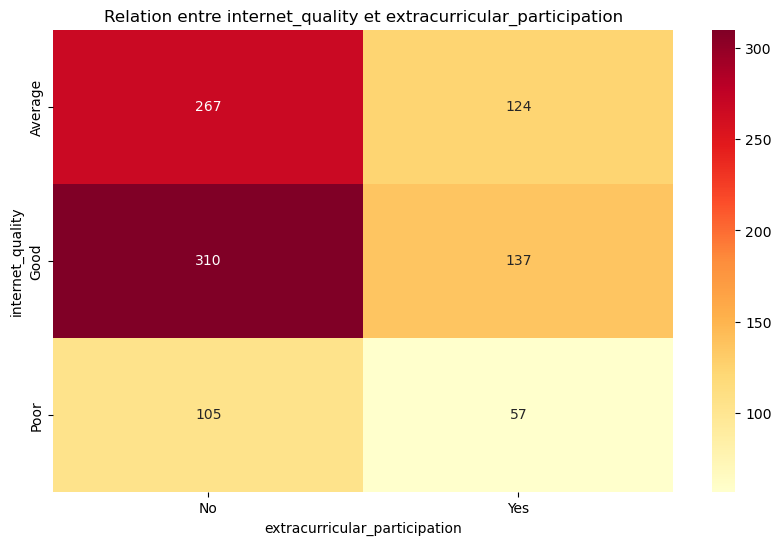


Résultats du Test du Khi-2 :
- Statistique Khi-2 : 1.13
- P-value : 0.5682
👉 Conclusion : internet_quality et extracurricular_participation semblent être indépendantes (p > 0.05).


In [37]:


# 1. Sélection de toutes les variables qualitatives
cols_quali = data.select_dtypes(include=['object']).columns

# 2. On génère toutes les combinaisons possibles de paires (ex: Genre vs Education)
paires_quali = list(itertools.combinations(cols_quali, 2))

print(f"Nombre de paires qualitatives à analyser : {len(paires_quali)}")

for var1, var2 in paires_quali:
    print(f"\n" + "="*50)
    print(f"ANALYSE : {var1} vs {var2}")
    print("="*50)
    
    # --- A) TABLEAU DE CONTINGENCE (nij) ---
    # Conforme à la Figure 31 du cours
    conf_table = pd.crosstab(data[var1], data[var2])
    print("\nTableau de contingence (Effectifs observés) :")
    display(conf_table)
    
    # --- B) VISUALISATION (Heatmap) ---
    plt.figure(figsize=(10, 6))
    sns.heatmap(conf_table, annot=True, fmt="d", cmap="YlOrRd")
    plt.title(f"Relation entre {var1} et {var2}")
    plt.show()
    
    # --- C) TEST DU KHI-2 (Indépendance) ---
    # Calcul de l'écart entre observé (nij) et théorique (fi*nj) - Pages 69-71
    chi2, p_val, dof, expected = st.chi2_contingency(conf_table)
    
    print(f"\nRésultats du Test du Khi-2 :")
    print(f"- Statistique Khi-2 : {chi2:.2f}")
    print(f"- P-value : {p_val:.4f}")
    
    # Interprétation selon le seuil de 5% du cours
    if p_val < 0.05:
        print(f"👉 Conclusion : Il existe un lien statistiquement significatif entre {var1} et {var2}.")
    else:
        print(f"👉 Conclusion : {var1} et {var2} semblent être indépendantes (p > 0.05).")

### -------------------l’Analyse en Composantes Principales (ACP)------------

### première étape :centrer et réduire les variables quantitatives

In [40]:


# Sélection des variables quantitatives uniquement
data_pca = data.select_dtypes(include=[np.number])
features = data_pca.columns

# Centrage et Réduction
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

print("Données centrées et réduites avec succès.")

Données centrées et réduites avec succès.


### projection + analyse de l’inertie/variance

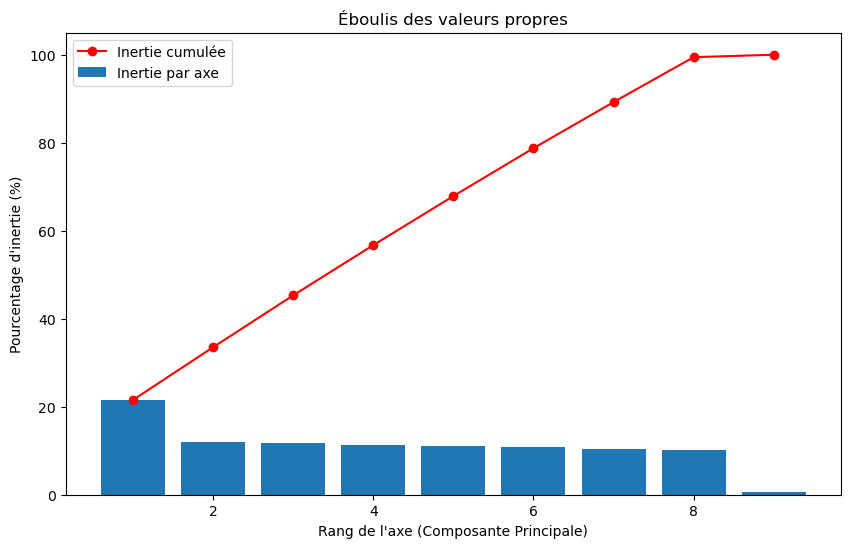

Inertie des deux premiers axes (F1+F2) : 33.54%


In [42]:
# Initialisation de l'ACP
pca = PCA()
pca_projected = pca.fit_transform(data_scaled)

# Calcul du pourcentage d'inertie (variance expliquée)
scree = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(scree))+1, scree, label="Inertie par axe")
plt.plot(np.arange(len(scree))+1, np.cumsum(scree), marker='o', color='red', label="Inertie cumulée")
plt.xlabel("Rang de l'axe (Composante Principale)")
plt.ylabel("Pourcentage d'inertie (%)")
plt.title("Éboulis des valeurs propres")
plt.legend()
plt.show()

print(f"Inertie des deux premiers axes (F1+F2) : {scree[0]+scree[1]:.2f}%")

### le Cercle des Corrélations

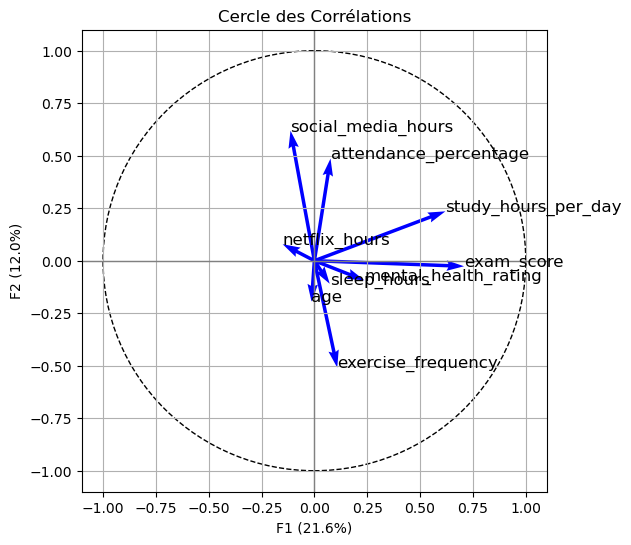

In [44]:
# Coordonnées des variables sur les axes
pcs = pca.components_

plt.figure(figsize=(6, 6))
plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]), pcs[0,:], pcs[1,:], 
           angles='xy', scale_units='xy', scale=1, color='blue')

# Ajout des labels des variables
for i, (x, y) in enumerate(zip(pcs[0,:], pcs[1,:])):
    plt.text(x, y, features[i], fontsize=12)

# Dessin du cercle
circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='black', linestyle='--')
plt.gca().add_artist(circle)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlabel(f"F1 ({scree[0]:.1f}%)")
plt.ylabel(f"F2 ({scree[1]:.1f}%)")
plt.title("Cercle des Corrélations")
plt.grid()
plt.show()

### projection des individus dans le plan des composantes principales

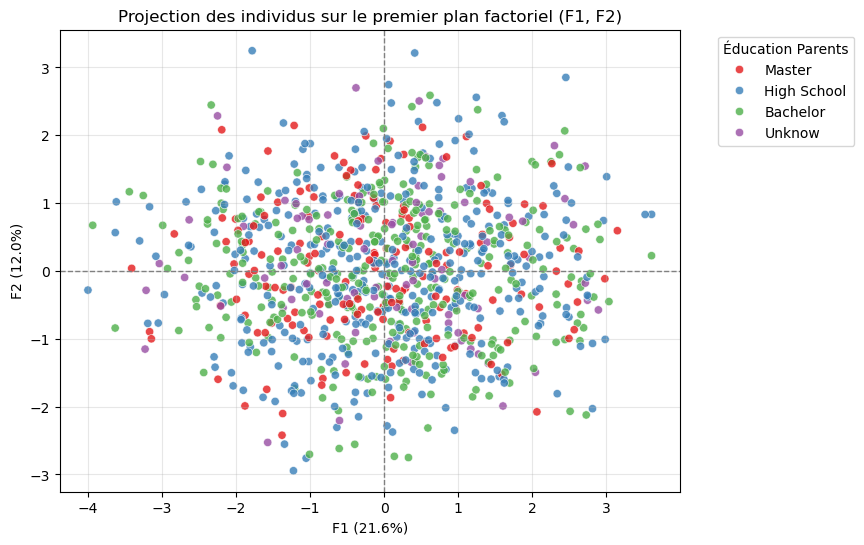

In [74]:
# coord contient les coordonnées de chaque étudiant sur les nouveaux axes F1, F2...
# On a calculé cela avec pca.fit_transform(data_scaled) précédemment

plt.figure(figsize=(8, 6))

# On affiche les individus. 'hue' permet de colorer selon une catégorie
sns.scatterplot(x=pca_projected[:, 0], y=pca_projected[:, 1], 
                hue=data['parental_education_level'], # On réutilise la variable quali ici
                palette='Set1', alpha=0.8)

# Ajout des lignes d'origine
plt.axhline(0, color='grey', linestyle='--', lw=1)
plt.axvline(0, color='grey', linestyle='--', lw=1)

# Titres et labels avec le pourcentage d'inertie
plt.xlabel(f"F1 ({scree[0]:.1f}%)")
plt.ylabel(f"F2 ({scree[1]:.1f}%)")
plt.title("Projection des individus sur le premier plan factoriel (F1, F2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Éducation Parents')
plt.grid(alpha=0.3)
plt.show()

In [47]:
# Calcul du cosinus carré pour chaque individu
# C'est le carré des coordonnées divisé par la distance au carré à l'origine
coords = pca_projected
dist_au_carre = np.sum(data_scaled**2, axis=1)
cos2 = coords**2 / dist_au_carre[:, np.newaxis]

# On affiche la qualité moyenne sur le premier plan
print(f"Qualité moyenne de représentation sur le plan F1-F2 : {np.mean(np.sum(cos2[:, :2], axis=1)):.2f}")

Qualité moyenne de représentation sur le plan F1-F2 : 0.31
